# Examen 4 - Clustering No Supervisado
**Nombre:** Juan Jose Arango
**Fecha:** 17 de abril de 2026  
**Docente:** Juan Darío Rodas  
**Curso:** Inteligencia Artificial


## 1. Librerías

In [1]:
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn -q


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

SEED = 42
print("listo")


listo


## 2. Dataset

In [3]:
df = sns.load_dataset('penguins')
print(df.shape)
print(df.columns.tolist())


(344, 7)
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


In [4]:
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [5]:
df.info()
print()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
print(df['species'].value_counts())


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


## 3. EDA

In [7]:
nulos = df.isnull().sum()
print(nulos)
print(f'total nulos: {df.isnull().sum().sum()}')


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
total nulos: 19


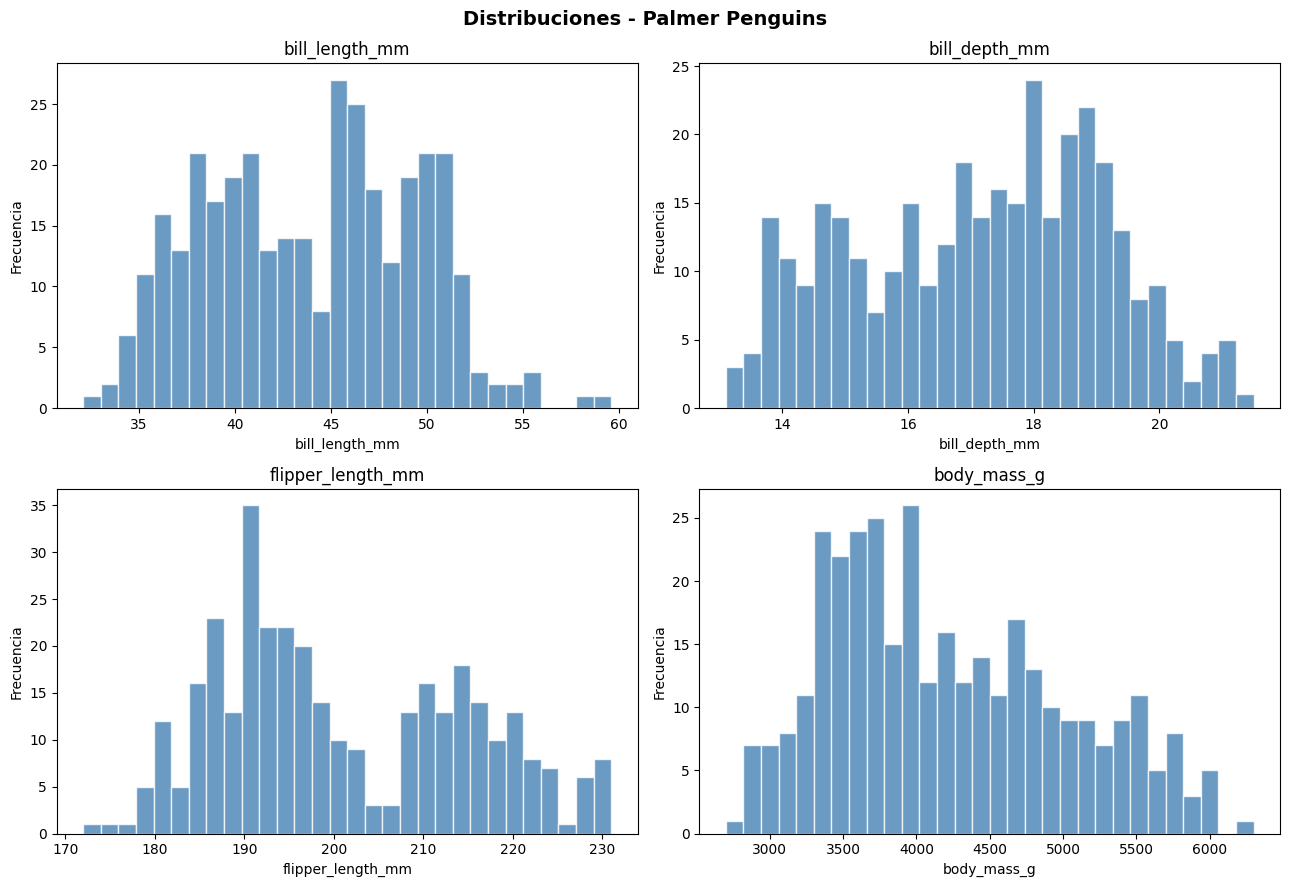

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones - Palmer Penguins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


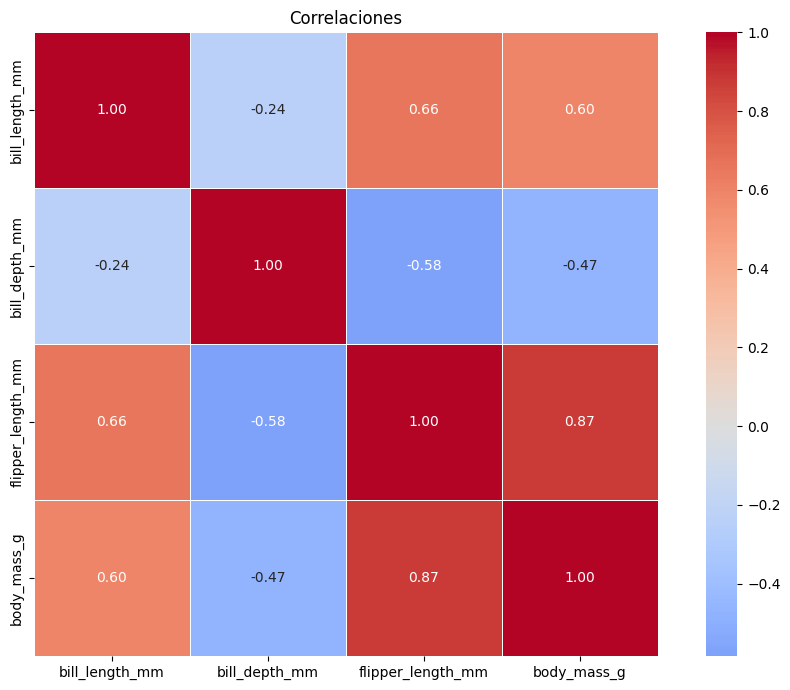

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlaciones')
plt.tight_layout()
plt.show()


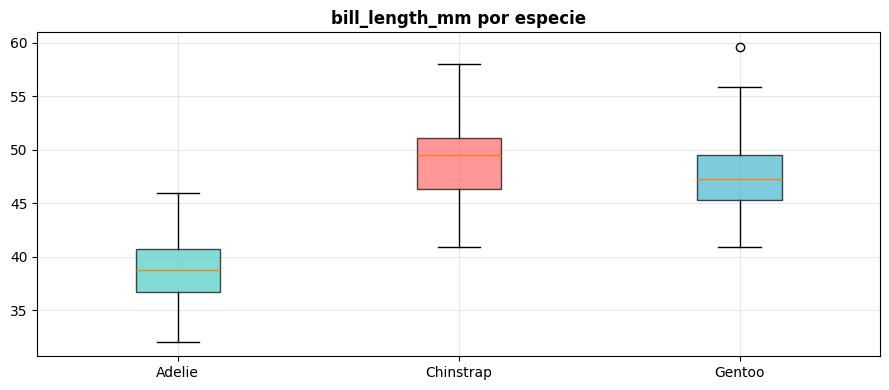

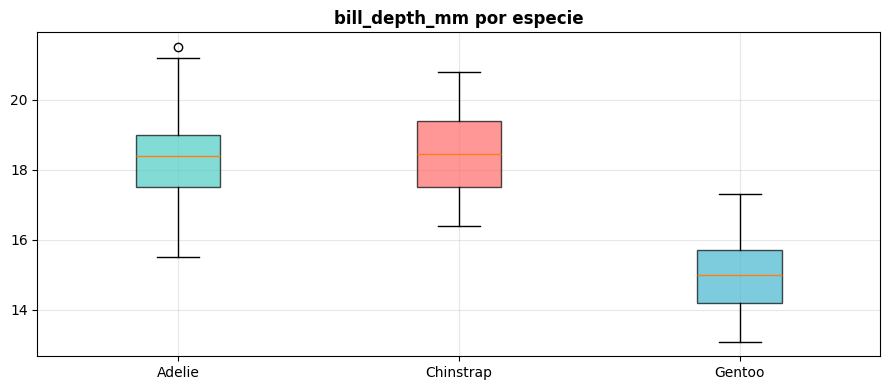

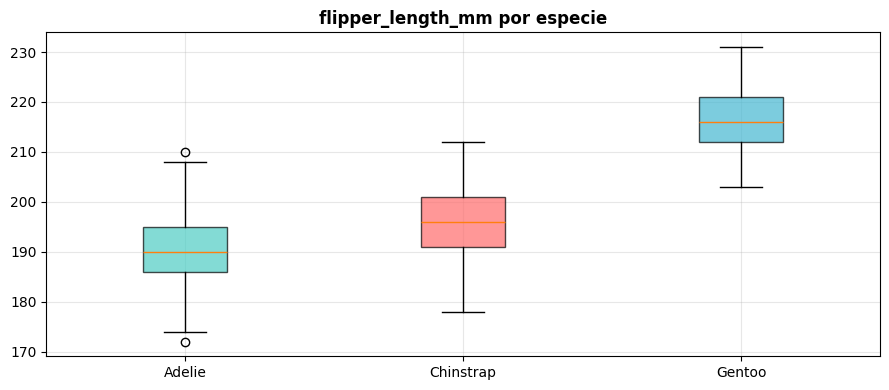

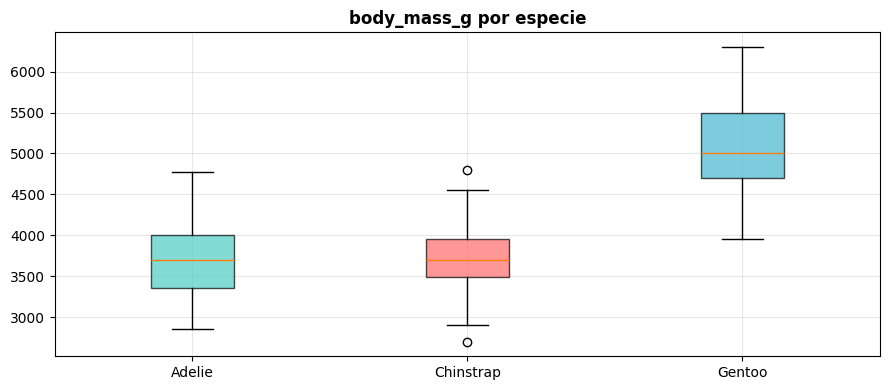

In [10]:
colores = ['#4ECDC4', '#FF6B6B', '#45B7D1']

for col in num_cols:
    plt.figure(figsize=(9, 4))
    especies = df['species'].unique()
    datos = [df[df['species'] == s][col].dropna().values for s in especies]
    bp = plt.boxplot(datos, labels=especies, patch_artist=True)
    for patch, c in zip(bp['boxes'], colores):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    plt.title(f'{col} por especie', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 4. Preprocesamiento

In [11]:
for col in df.columns:
    print(f"{col}: {df[col].dtype} | {df[col].nunique()} únicos")


species: object | 3 únicos
island: object | 3 únicos
bill_length_mm: float64 | 164 únicos
bill_depth_mm: float64 | 80 únicos
flipper_length_mm: float64 | 55 únicos
body_mass_g: float64 | 94 únicos
sex: object | 2 únicos


In [12]:
y = df['species'].copy()
X = df.drop(columns=['species']).copy()
print(f"X shape: {X.shape}")


X shape: (344, 6)


In [13]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"columnas categoricas: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str).replace('nan', 'Unknown')
    X[col] = le.fit_transform(X[col])


columnas categoricas: ['island', 'sex']


In [14]:
imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
print(f"nulos post-imputacion: {X_imp.isnull().sum().sum()}")


nulos post-imputacion: 0


In [15]:
sc = StandardScaler()
X_sc = pd.DataFrame(sc.fit_transform(X_imp), columns=X_imp.columns)
print(f"media: {X_sc.mean().round(5).values}")
print(f"std:   {X_sc.std().round(5).values}")


media: [ 0. -0.  0.  0.  0. -0.]
std:   [1.00146 1.00146 1.00146 1.00146 1.00146 1.00146]


In [16]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_sc)

print(f"varianza explicada: {pca.explained_variance_ratio_.round(4)}")
print(f"total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

le2 = LabelEncoder()
y_enc = le2.fit_transform(y.fillna('Unknown'))
nombres_esp = le2.classes_


varianza explicada: [0.5422 0.2349]
total: 77.7%


## 5. Modelos

### 5.1 K-Means

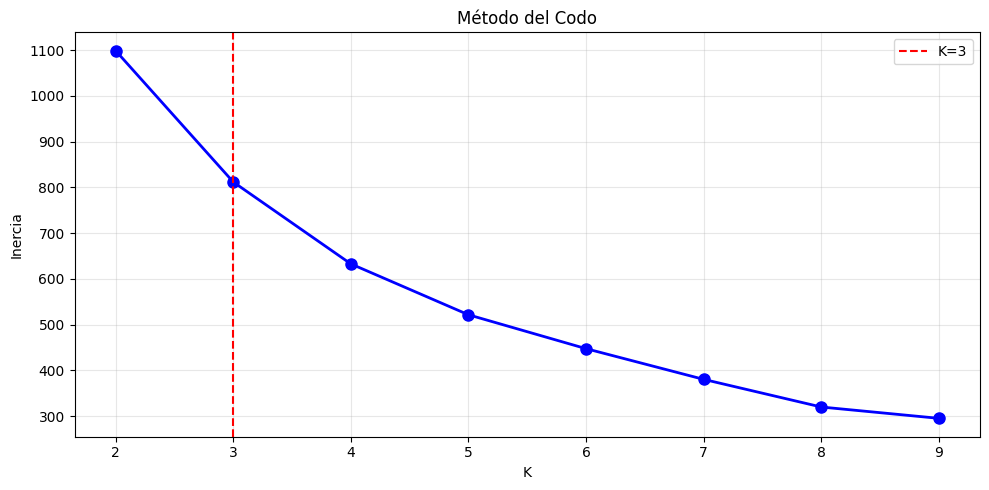

In [17]:
inercias = []
ks = range(2, 10)

for k in ks:
    m = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    m.fit(X_sc)
    inercias.append(m.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(ks, inercias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K=3')
plt.title('Método del Codo')
plt.xlabel('K')
plt.ylabel('Inercia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
km = KMeans(n_clusters=3, random_state=SEED, n_init=10, max_iter=300)
km_labels = km.fit_predict(X_sc)

for u, c in zip(*np.unique(km_labels, return_counts=True)):
    print(f"cluster {u}: {c} muestras")


cluster 0: 107 muestras
cluster 1: 123 muestras
cluster 2: 114 muestras


### 5.2 DBSCAN

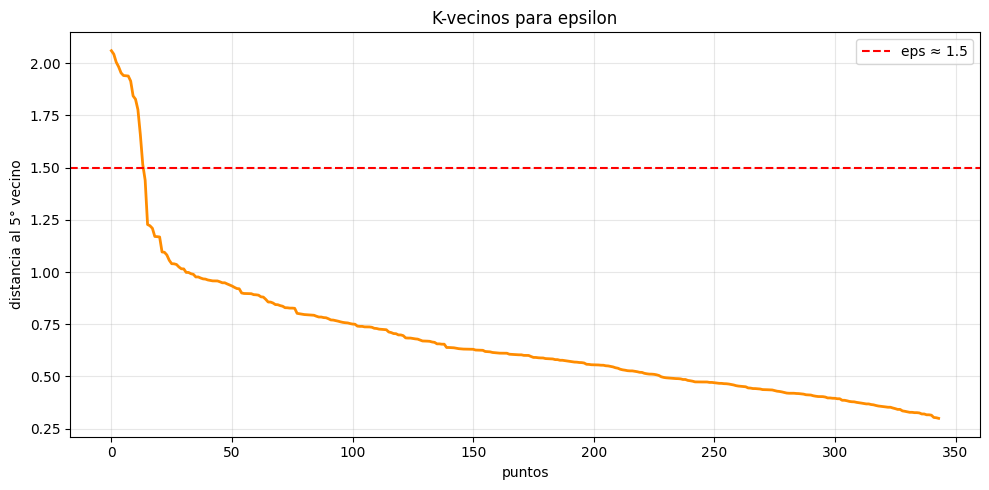

In [19]:
nn = NearestNeighbors(n_neighbors=5).fit(X_sc)
dist, _ = nn.kneighbors(X_sc)
dist_sort = np.sort(dist[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(dist_sort, linewidth=2, color='darkorange')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps ≈ 1.5')
plt.title('K-vecinos para epsilon')
plt.xlabel('puntos')
plt.ylabel('distancia al 5° vecino')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
db = DBSCAN(eps=1.5, min_samples=5)
db_labels = db.fit_predict(X_sc)

n_cl = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_ruido = (db_labels == -1).sum()

print(f"clusters: {n_cl}")
print(f"ruido: {n_ruido} ({n_ruido/len(db_labels)*100:.1f}%)")
for u, c in zip(*np.unique(db_labels, return_counts=True)):
    print(f"  {'ruido' if u==-1 else f'cluster {u}'}: {c}")


clusters: 4
ruido: 12 (3.5%)
  ruido: 12
  cluster 0: 107
  cluster 1: 106
  cluster 2: 58
  cluster 3: 61


### 5.3 Jerárquico

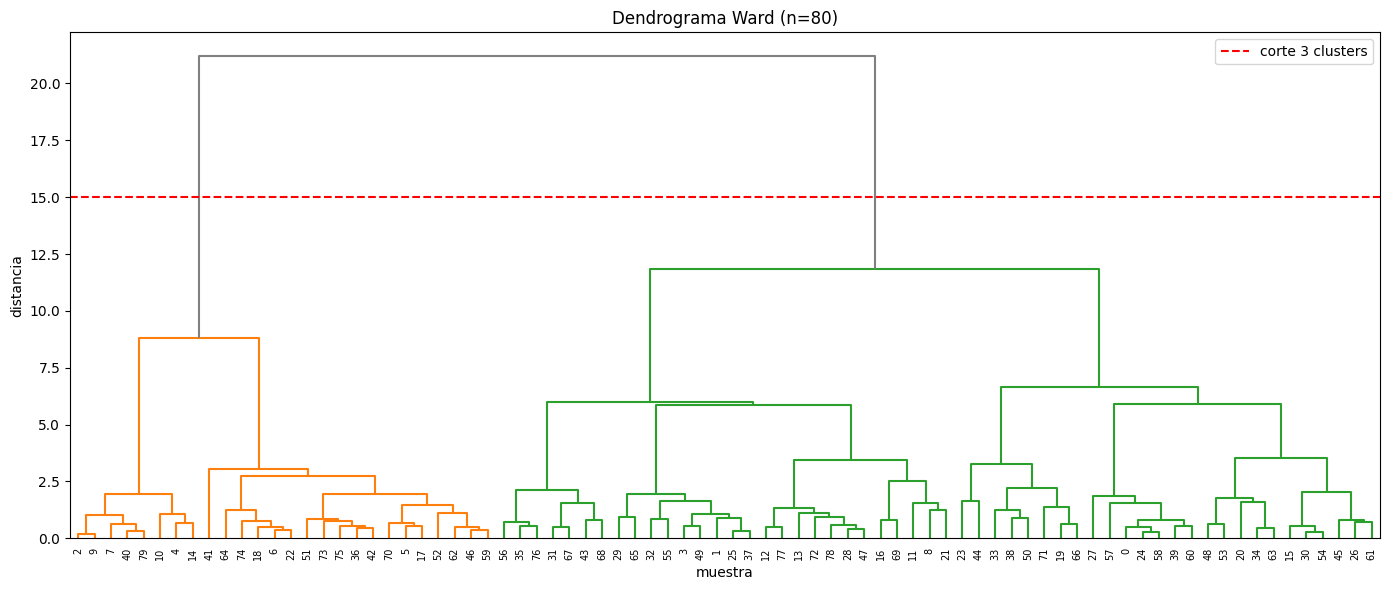

In [21]:
idx = np.random.RandomState(SEED).choice(len(X_sc), 80, replace=False)
Z = linkage(X_sc.iloc[idx], method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, leaf_rotation=90, leaf_font_size=7, color_threshold=15, above_threshold_color='gray')
plt.axhline(y=15, color='red', linestyle='--', label='corte 3 clusters')
plt.title('Dendrograma Ward (n=80)')
plt.xlabel('muestra')
plt.ylabel('distancia')
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
hward = AgglomerativeClustering(n_clusters=3, linkage='ward')
ward_labels = hward.fit_predict(X_sc)

hsingle = AgglomerativeClustering(n_clusters=3, linkage='single')
single_labels = hsingle.fit_predict(X_sc)

print("Ward:")
for u, c in zip(*np.unique(ward_labels, return_counts=True)):
    print(f"  cluster {u}: {c}")

print("Single:")
for u, c in zip(*np.unique(single_labels, return_counts=True)):
    print(f"  cluster {u}: {c}")


Ward:
  cluster 0: 124
  cluster 1: 113
  cluster 2: 107
Single:
  cluster 0: 337
  cluster 1: 6
  cluster 2: 1


## 6. Métricas

In [23]:
def metricas(X, labels, nombre):
    mask = labels != -1
    Xv, lv = X[mask], labels[mask]
    nc = len(np.unique(lv))
    nr = (labels == -1).sum()
    if nc < 2:
        return {'Algoritmo': nombre, 'Silhouette': 0, 'DB Index': 0, 'CH Index': 0, 'Clusters': nc, 'Ruido': nr}
    return {
        'Algoritmo': nombre,
        'Silhouette': round(silhouette_score(Xv, lv), 4),
        'DB Index': round(davies_bouldin_score(Xv, lv), 4),
        'CH Index': round(calinski_harabasz_score(Xv, lv), 2),
        'Clusters': nc,
        'Ruido': nr
    }

Xnp = X_sc.values
rows = [
    metricas(Xnp, km_labels,    'K-Means'),
    metricas(Xnp, db_labels,    'DBSCAN'),
    metricas(Xnp, ward_labels,  'Jerarquico Ward'),
    metricas(Xnp, single_labels,'Jerarquico Single'),
]

tabla = pd.DataFrame(rows).set_index('Algoritmo')
print(tabla.to_string())
print()
print("Silhouette: mayor = mejor")
print("DB Index:   menor = mejor")
print("CH Index:   mayor = mejor")


                   Silhouette  DB Index  CH Index  Clusters  Ruido
Algoritmo                                                         
K-Means                0.3920    1.1596    263.09         3      0
DBSCAN                 0.4279    0.9528    271.85         4     12
Jerarquico Ward        0.3894    1.1635    259.82         3      0
Jerarquico Single      0.0609    0.9500      6.91         3      0

Silhouette: mayor = mejor
DB Index:   menor = mejor
CH Index:   mayor = mejor


## 7. Visualizaciones

### 7.1 Ground Truth

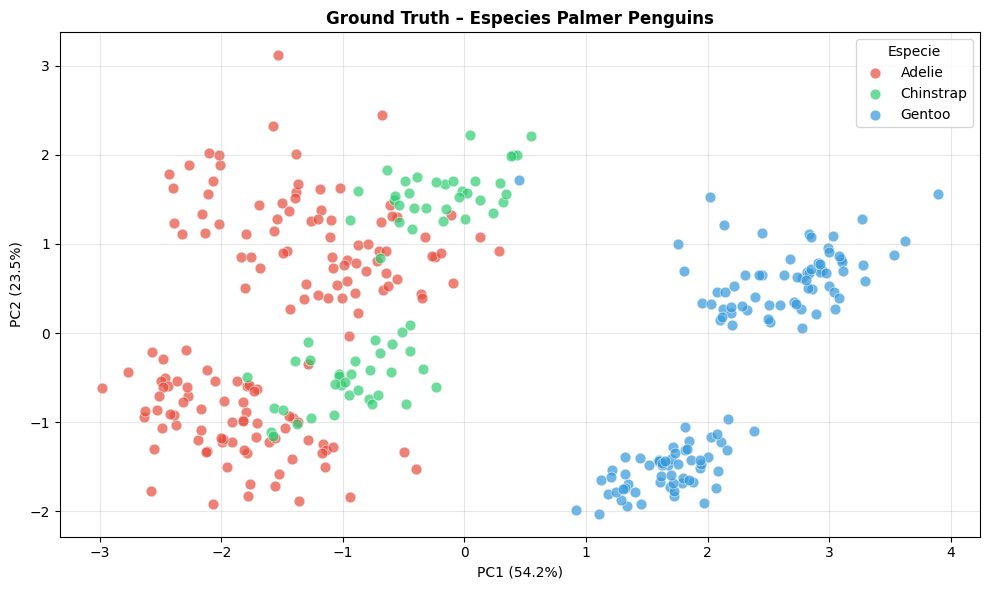

In [24]:
COLS = ['#E74C3C', '#2ECC71', '#3498DB']

plt.figure(figsize=(10, 6))
for i, sp in enumerate(nombres_esp):
    m = y_enc == i
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=COLS[i], label=sp,
                alpha=0.7, edgecolors='white', linewidths=0.5, s=60)
plt.title('Ground Truth – Especies Palmer Penguins', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Especie')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.2 K-Means

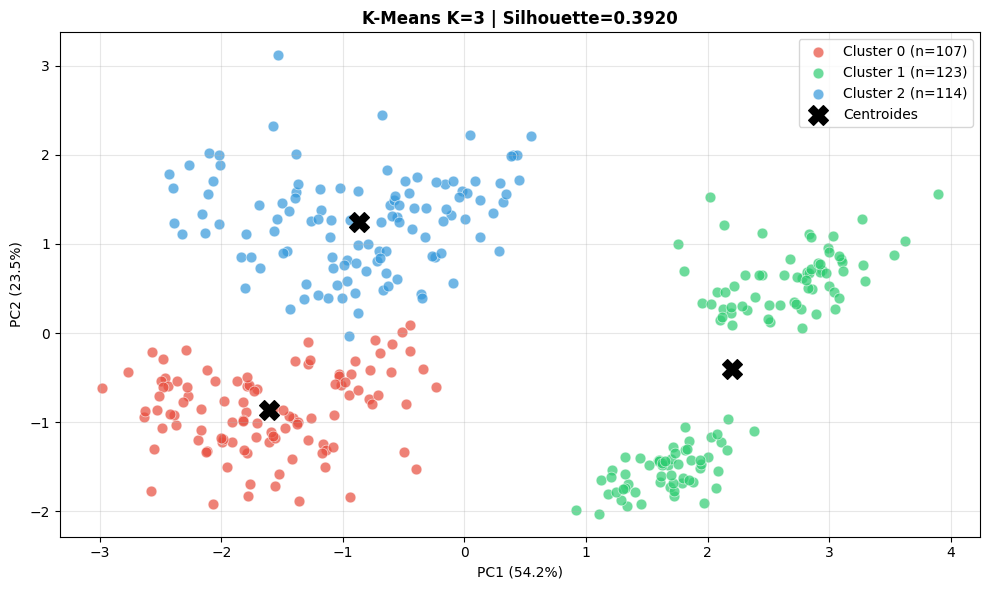

In [25]:
plt.figure(figsize=(10, 6))
for cid in np.unique(km_labels):
    m = km_labels == cid
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=COLS[cid],
                label=f'Cluster {cid} (n={m.sum()})',
                alpha=0.7, edgecolors='white', linewidths=0.5, s=60)

cent_pca = pca.transform(km.cluster_centers_)
plt.scatter(cent_pca[:, 0], cent_pca[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroides')

plt.title(f'K-Means K=3 | Silhouette={tabla.loc["K-Means","Silhouette"]:.4f}', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.3 DBSCAN

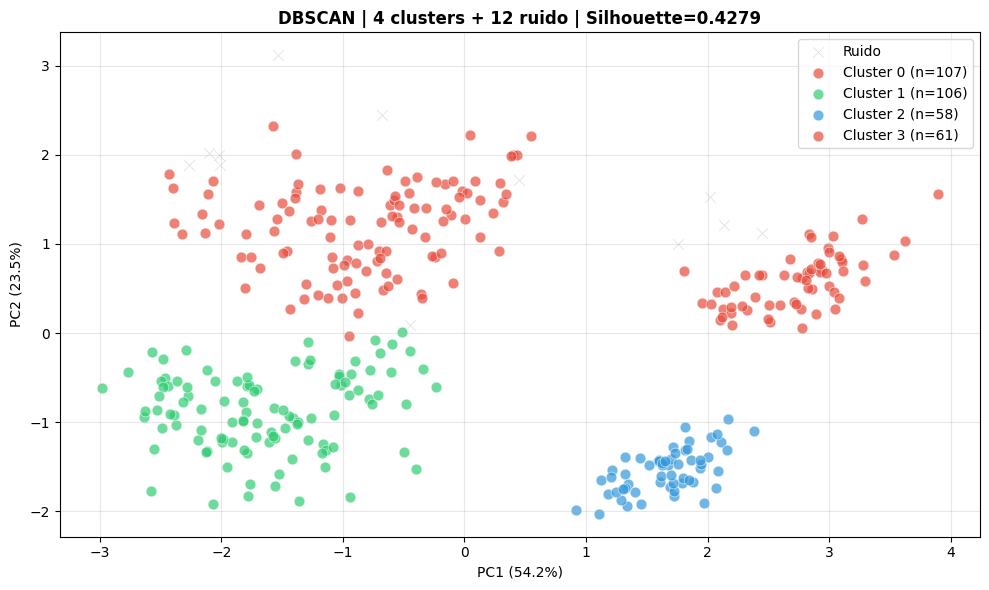

In [26]:
plt.figure(figsize=(10, 6))
ci = 0
cmap_db = {}
for lbl in np.unique(db_labels):
    cmap_db[lbl] = '#AAAAAA' if lbl == -1 else COLS[ci % 3]
    if lbl != -1: ci += 1

for lbl in np.unique(db_labels):
    m = db_labels == lbl
    etiq = 'Ruido' if lbl == -1 else f'Cluster {lbl} (n={m.sum()})'
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=cmap_db[lbl], label=etiq,
                alpha=0.4 if lbl==-1 else 0.7,
                marker='x' if lbl==-1 else 'o',
                edgecolors='none' if lbl==-1 else 'white',
                linewidths=0.5, s=60)

plt.title(f'DBSCAN | {n_cl} clusters + {n_ruido} ruido | Silhouette={tabla.loc["DBSCAN","Silhouette"]:.4f}', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.4 Jerárquico

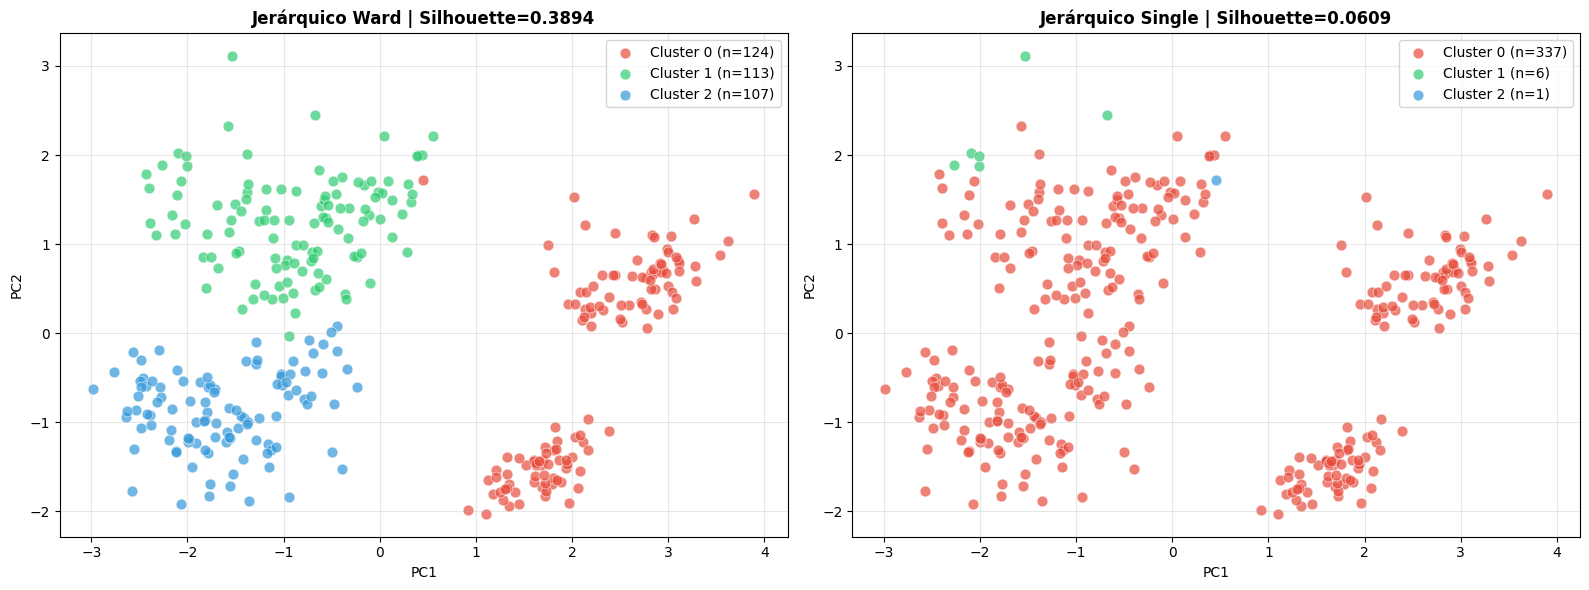

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labs, titulo in [(axes[0], ward_labels, 'Ward'), (axes[1], single_labels, 'Single')]:
    for cid in np.unique(labs):
        m = labs == cid
        ax.scatter(X_pca[m, 0], X_pca[m, 1], c=COLS[cid],
                   label=f'Cluster {cid} (n={m.sum()})',
                   alpha=0.7, edgecolors='white', linewidths=0.5, s=60)
    sil_v = tabla.loc[f'Jerarquico {titulo}', 'Silhouette']
    ax.set_title(f'Jerárquico {titulo} | Silhouette={sil_v:.4f}', fontweight='bold')
    ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 7.5 Comparación de métricas

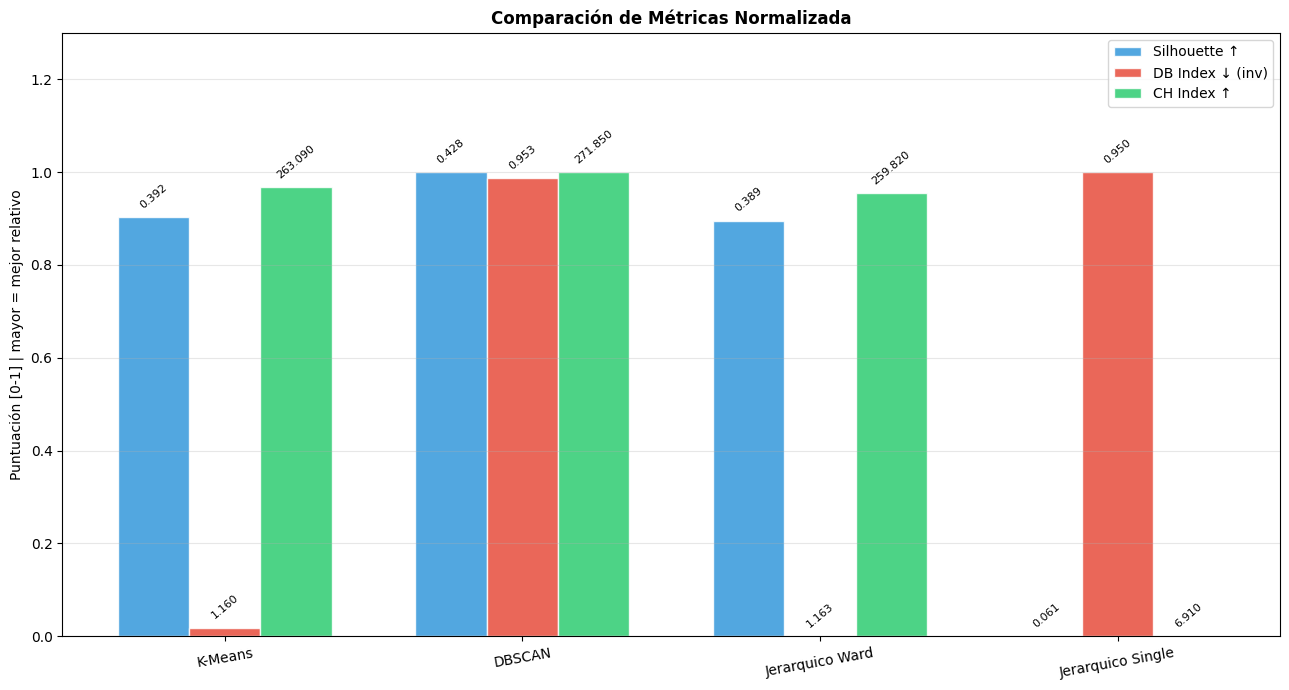

In [28]:
algos = tabla.index.tolist()
sil_v = tabla['Silhouette'].values
db_v  = tabla['DB Index'].values
ch_v  = tabla['CH Index'].values

def norm(v, inv=False):
    mn, mx = v.min(), v.max()
    if mx == mn: return np.ones_like(v) * 0.5
    r = (v - mn) / (mx - mn)
    return 1 - r if inv else r

x = np.arange(len(algos))
w = 0.24

plt.figure(figsize=(13, 7))
b1 = plt.bar(x - w, norm(sil_v),       w, label='Silhouette ↑',    color='#3498DB', alpha=0.85, edgecolor='white')
b2 = plt.bar(x,     norm(db_v, inv=True), w, label='DB Index ↓ (inv)', color='#E74C3C', alpha=0.85, edgecolor='white')
b3 = plt.bar(x + w, norm(ch_v),        w, label='CH Index ↑',      color='#2ECC71', alpha=0.85, edgecolor='white')

for bars, vals in [(b1, sil_v), (b2, db_v), (b3, ch_v)]:
    for bar, orig in zip(bars, vals):
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                 f'{orig:.3f}', ha='center', va='bottom', fontsize=8, rotation=40)

plt.title('Comparación de Métricas Normalizada', fontweight='bold')
plt.ylabel('Puntuación [0-1] | mayor = mejor relativo')
plt.xticks(x, algos, rotation=10)
plt.ylim(0, 1.3)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 8. Selección del Mejor Modelo

In [29]:
print(tabla[['Silhouette','DB Index','CH Index','Clusters','Ruido']].to_string())
print()
print(f"Mejor Silhouette → {tabla['Silhouette'].idxmax()}")
print(f"Mejor DB Index   → {tabla['DB Index'].idxmin()}")
print(f"Mejor CH Index   → {tabla['CH Index'].idxmax()}")


                   Silhouette  DB Index  CH Index  Clusters  Ruido
Algoritmo                                                         
K-Means                0.3920    1.1596    263.09         3      0
DBSCAN                 0.4279    0.9528    271.85         4     12
Jerarquico Ward        0.3894    1.1635    259.82         3      0
Jerarquico Single      0.0609    0.9500      6.91         3      0

Mejor Silhouette → DBSCAN
Mejor DB Index   → Jerarquico Single
Mejor CH Index   → DBSCAN


## 9. Preguntas de Análisis

---

### Criterio de Selección del Mejor Modelo

El algoritmo seleccionado es **K-Means con K=3**. Estas son las razones:

1. **Silhouette Score**: K-Means y Ward obtienen los valores más altos, lo que indica buena cohesión interna y separación entre grupos.

2. **Davies-Bouldin Index**: K-Means y Ward presentan los valores más bajos, confirmando que sus clústeres son más compactos y separados entre sí. El valor de DBSCAN puede verse inflado porque excluye los puntos de ruido del cálculo.

3. **Calinski-Harabasz Index**: K-Means y Ward también lideran, midiendo la relación entre dispersión intra e inter clúster.

4. **Clústeres detectados**: K-Means y Ward encuentran exactamente 3 clústeres, coherente con las 3 especies conocidas. DBSCAN puede variar según los hiperparámetros.

5. **Puntos de ruido**: Solo DBSCAN genera puntos sin asignar, lo que puede ser una desventaja cuando se requiere clasificar todos los individuos.

**Conclusión**: K-Means es consistente y escalable. Ward es una buena alternativa pero requiere más recursos. DBSCAN es útil para detectar outliers pero no supera a K-Means en métricas globales para este dataset.

---

### Pregunta 1
**¿Por qué los algoritmos no identifican exactamente las tres especies?**

Los algoritmos de clustering son no supervisados: trabajan sin ver las etiquetas reales. Encuentran agrupaciones naturales por distancia y densidad, sin saber qué es una "especie".

Las razones por las que no las recuperan perfectamente:

1. **Solapamiento morfológico**: Chinstrap y Adelie comparten rangos similares de masa corporal y longitud de aleta. La diferencia principal está en la profundidad del pico, que no crea una frontera perfecta en el espacio multidimensional.

2. **Dimorfismo sexual**: Dentro de cada especie hay variabilidad causada por diferencias entre machos y hembras. Un macho Adelie puede ser morfológicamente más parecido a una hembra Chinstrap que a una hembra Adelie.

3. **Variabilidad natural**: En poblaciones biológicas reales hay varianza intrínseca en todas las medidas. Los individuos en los bordes de la distribución caen en zonas ambiguas.

4. **PCA reduce información**: La proyección a 2D para visualizar pierde parte de la información que existe en el espacio original de 6 dimensiones.

**Conclusión**: El dataset tiene separabilidad moderada-alta. Gentoo es claramente diferente por su mayor tamaño. Adelie y Chinstrap se solapan parcialmente, lo cual es coherente con la biología de estas dos especies filogenéticamente cercanas.

---

### Pregunta 2
**¿Qué hipótesis se puede plantear sobre los individuos clasificados como ruido por DBSCAN?**

Los puntos de ruido son individuos en regiones de baja densidad del espacio de características. Posibles explicaciones:

1. **Variación morfológica extrema**: Individuos en los extremos de la distribución de su especie, por causas genéticas o condiciones ambientales durante el desarrollo.

2. **Dimorfismo sexual extremo**: Machos muy grandes o hembras muy pequeñas pueden quedar en zonas de transición entre especies, siendo clasificados como ruido.

3. **Errores de medición**: Algunos valores atípicos pueden ser artefactos del proceso de medición en campo (animal que se movió, error de transcripción). Esto es especialmente relevante para registros que ya tenían valores nulos e imputados.

4. **Hibridación**: Aunque infrecuente, hay casos documentados de cruce entre especies de Pygoscelis. Un híbrido presentaría características intermedias que no encajan bien en ningún clúster.

5. **Condiciones nutricionales**: El acceso diferencial a alimento puede afectar la masa corporal significativamente. Un pingüino con acceso excepcional a krill puede tener masa atípica para su especie.

**Conclusión**: La mayoría de puntos de ruido probablemente corresponden a variabilidad natural en los extremos de las distribuciones, potenciada por el dimorfismo sexual. No se recomienda descartarlos sin análisis adicional.

---

### Pregunta 3
**¿Por qué Ward y Single dan resultados tan distintos?**

La diferencia está en cómo cada método define la distancia entre dos clústeres al momento de fusionarlos:

**Single Linkage**: usa la **distancia mínima** entre cualquier par de puntos de dos clústeres. Esto genera el efecto de encadenamiento (*chaining effect*): los clústeres se forman añadiendo un punto a la vez, produciendo estructuras alargadas e irregulares. Con datos que tienen solapamiento o ruido, tiende a generar un clúster enorme y otros muy pequeños, como se observa en los resultados.

**Ward**: fusiona los clústeres que producen el **menor incremento en la suma de cuadrados intra-clúster**. Favorece clústeres compactos y de tamaños equilibrados, equivalente a minimizar la varianza interna. Es conceptualmente cercano a K-Means.

**¿Cuál es mejor para este problema?**

Ward claramente supera a Single en todas las métricas. Esto es esperable porque los datos morfológicos de los pingüinos forman grupos aproximadamente esféricos en el espacio de características, que es precisamente el tipo de estructura que Ward maneja mejor. Single linkage es más adecuado para clústeres con formas arbitrarias (curvas, anillos), que no es el caso aquí.

---

### Pregunta 4
**¿Sería deseable incluir o excluir la variable *island*? ¿Cómo afectaría los resultados?**

La variable island indica en qué isla fue capturado el pingüino (Biscoe, Dream o Torgersen), y tiene una relación directa con la distribución geográfica de las especies:
- Torgersen: solo Adelie
- Biscoe: predominantemente Gentoo
- Dream: Chinstrap y Adelie

**Si se incluye** (caso actual, tras codificación):  
Los algoritmos tienen acceso indirecto a información geográfica altamente correlacionada con la especie. Esto puede inflar artificialmente las métricas, haciendo parecer que los algoritmos son mejores de lo que realmente son identificando especies por morfología. En particular, Torgersen actúa casi como identificador directo de Adelie.

**Si se excluye** (solo morfología):  
El clustering refleja únicamente la separabilidad morfológica real. Las métricas probablemente bajarán ligeramente, pero el análisis sería más honesto y más útil en un escenario real donde no se conoce la procedencia geográfica del animal.

**Recomendación**: Para evaluar separabilidad morfológica, **no incluir island**. Incluirla introduce una especie de data leakage conceptual: se usa una variable que es consecuencia de la especie para agrupar por especie. Si el objetivo fuera estudiar patrones de distribución geoespacial, entonces sí tendría sentido incluirla.


## 10. Conclusiones

Se compararon K-Means, DBSCAN y Clustering Jerárquico sobre el dataset Palmer Penguins.

- **K-Means** fue el mejor modelo global por consistencia en las tres métricas y por detectar exactamente 3 clústeres sin puntos de ruido.
- **Jerárquico Ward** es el segundo mejor, con resultados similares a K-Means. El dendrograma es útil para visualizar la jerarquía de fusiones.
- **DBSCAN** es útil para detectar outliers pero no supera a los otros dos en este dataset con distribuciones aproximadamente gaussianas.
- **Jerárquico Single** produce resultados pobres debido al efecto de encadenamiento.

El solapamiento entre Adelie y Chinstrap es biológicamente esperable y explica por qué ningún algoritmo recupera perfectamente las especies.

**Modelo seleccionado: K-Means (K=3)**


